In [17]:
import yfinance as yf
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

In [10]:
ticker = "AAPL"
data = yf.download(ticker, start="2026-01-01", end="2026-09-24")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-01-02,270.274353,277.085800,268.269799,271.520960,37838100
2026-01-05,266.534546,270.773009,265.417591,269.905376,45647200
2026-01-06,261.647827,266.823742,261.408488,266.275247,52352100
2026-01-07,259.623322,262.964234,259.104744,262.485556,48309800
2026-01-08,258.336823,258.586144,255.005878,256.322286,50419300


In [12]:
data = data.dropna()
data.reset_index(inplace=True)

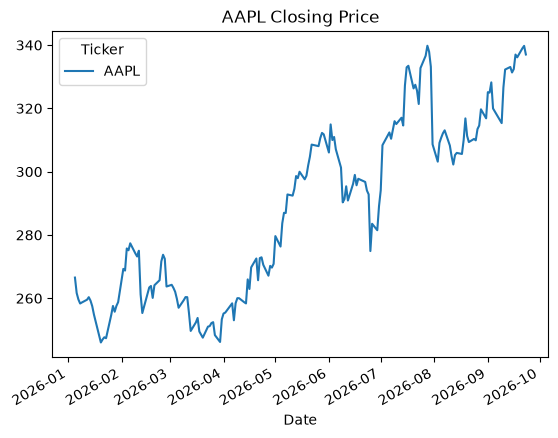

In [13]:
data['daily_return'] = data['Close'].pct_change()


data.plot(x='Date', y='Close', title=f'{ticker} Closing Price')
plt.show()

In [14]:
data.to_csv('../data/aapl_2026.csv', index=False)

In [21]:
conn = sqlite3.connect('../data/finance.db')
data.to_sql('aapl_prices', conn, if_exists='replace', index=False)
#conn.close()

181

In [22]:
pd.read_sql('SELECT * FROM aapl_prices LIMIT 5', conn)

,"('Date', '')","('Close', 'AAPL')","('High', 'AAPL')","('Low', 'AAPL')","('Open', 'AAPL')","('Volume', 'AAPL')","('daily_return', '')"
0,2026-01-05 00:00:00,266.534546,270.773009,265.417591,269.905376,45647200,NaN
1,2026-01-06 00:00:00,261.647827,266.823742,261.408488,266.275247,52352100,-0.018334
2,2026-01-07 00:00:00,259.623322,262.964234,259.104744,262.485556,48309800,-0.007738
3,2026-01-08 00:00:00,258.336823,258.586144,255.005878,256.322286,50419300,-0.004955
4,2026-01-09 00:00:00,258.665924,259.503640,255.524481,258.376703,39997000,0.001274
